# L13 Reinforcement Learning: Interactive MAB and MDP Notebook

Author: CodeX and Weikai YANG

This notebook is a hands-on companion to `L13_RL_26Spring.tex`.

It has two blocks.

1. Multi-armed bandits (MAB): manually pull arms, compute regret, and compare simple policies.
2. Markov decision processes (MDP): reproduce the machine-maintenance example with finite-horizon dynamic programming and fixed-policy value evaluation.

Run the cells from top to bottom.
The interactive parts use `ipywidgets`; if widgets do not render in your environment, the same functions can still be called directly.


## Imports and display helpers


In [1]:
import html
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, clear_output, display

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except Exception:
    widgets = None
    WIDGETS_AVAILABLE = False

%matplotlib inline

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10.5,
    }
)


def records_to_html(records, float_digits=3):
    if not records:
        return HTML("<em>No records yet.</em>")

    columns = list(records[0].keys())
    header = "".join(f"<th>{html.escape(str(col))}</th>" for col in columns)
    body_rows = []

    for row in records:
        cells = []
        for col in columns:
            value = row[col]
            if isinstance(value, (float, np.floating)):
                value = f"{value:.{float_digits}f}"
            cells.append(f"<td>{html.escape(str(value))}</td>")
        body_rows.append("<tr>" + "".join(cells) + "</tr>")

    style = (
        "<style>"
        "table.rl-table {border-collapse: collapse; margin: 0.6em 0;}"
        "table.rl-table th, table.rl-table td {border: 1px solid #ddd; padding: 4px 8px; text-align: right;}"
        "table.rl-table th:first-child, table.rl-table td:first-child {text-align: left;}"
        "table.rl-table th {background: #f5f5f5;}"
        "</style>"
    )
    table = f"{style}<table class='rl-table'><thead><tr>{header}</tr></thead><tbody>{''.join(body_rows)}</tbody></table>"
    return HTML(table)


print("ipywidgets available:", WIDGETS_AVAILABLE)


ipywidgets available: True


# Block 1: Multi-armed bandits

The lecture introduces MAB as reinforcement learning with a single state.
At each round we choose one arm and observe only that arm's random reward.
Here each arm is a Bernoulli arm with unknown success probability in the learning algorithm.

Regret is reported in two ways.

- Realized regret: $t \max_i p_i - \sum_{\tau=1}^t r_\tau$.
- Pseudo-regret: $\sum_{\tau=1}^t (\max_i p_i - p_{a_\tau})$.

The pseudo-regret curve is usually smoother because it compares expected rewards rather than sampled rewards.


In [6]:
DEFAULT_ARM_PROBS = np.array([0.15, 0.35, 0.55, 0.70], dtype=float)


class BernoulliBandit:
    def __init__(self, probs, rng=None):
        probs = np.asarray(probs, dtype=float)
        if probs.ndim != 1 or len(probs) == 0:
            raise ValueError("probs must be a non-empty one-dimensional array.")
        if np.any((probs < 0) | (probs > 1)):
            raise ValueError("All Bernoulli probabilities must be in [0, 1].")

        self.probs = probs
        self.rng = np.random.default_rng(rng)

    @property
    def n_arms(self):
        return len(self.probs)

    @property
    def best_arm(self):
        return int(np.argmax(self.probs))

    @property
    def best_mean(self):
        return float(np.max(self.probs))

    def pull(self, arm):
        arm = int(arm)
        if arm < 0 or arm >= self.n_arms:
            raise ValueError(f"arm must be between 0 and {self.n_arms - 1}.")
        return int(self.rng.random() < self.probs[arm])


def make_bandit(probs=DEFAULT_ARM_PROBS, seed=7):
    return BernoulliBandit(probs, rng=seed)


def show_bandit_parameters(probs=DEFAULT_ARM_PROBS):
    bandit = BernoulliBandit(probs, rng=0)
    rows = []
    for arm, prob in enumerate(bandit.probs):
        rows.append(
            {
                "Arm": f"{arm}",
                "Reward distribution": f"Bernoulli({prob:.2f})",
                "Expected reward": prob,
                "Best?": "yes" if arm == bandit.best_arm else "",
            }
        )
    display(records_to_html(rows))
    print(f"Best arm = {bandit.best_arm}; expected reward = {bandit.best_mean:.2f}")


show_bandit_parameters()


Arm,Reward distribution,Expected reward,Best?
0,Bernoulli(0.15),0.150,
1,Bernoulli(0.35),0.350,
2,Bernoulli(0.55),0.550,
3,Bernoulli(0.70),0.700,yes


Best arm = 3; expected reward = 0.70


## Manual arm pulling

The cell below creates arm buttons.
Click any arm freely for 10 rounds.
After each pull, the notebook updates the reward history and regret statistics.

You can restart with different true arm probabilities, for example:

```python
manual_state = start_manual_bandit(probs=[0.20, 0.40, 0.50, 0.80], horizon=10, seed=11)
```


In [ ]:
def manual_history_summary(history, bandit):
    cumulative_reward = sum(row["Reward"] for row in history)
    realized_regret = len(history) * bandit.best_mean - cumulative_reward
    pseudo_regret = sum(bandit.best_mean - bandit.probs[row["Arm"]] for row in history)
    return {
        "Pulls": len(history),
        "Total reward": cumulative_reward,
        "Realized regret": realized_regret,
        "Pseudo-regret": pseudo_regret,
    }


def start_manual_bandit(probs=DEFAULT_ARM_PROBS, horizon=10, seed=7):
    bandit = BernoulliBandit(probs, rng=seed)
    state = {
        "bandit": bandit,
        "horizon": int(horizon),
        "history": [],
    }

    if not WIDGETS_AVAILABLE:
        print("ipywidgets is not available. Use state['bandit'].pull(arm) manually instead.")
        return state

    out = widgets.Output()
    buttons = [
        widgets.Button(description=f"Pull arm {arm}", button_style="")
        for arm in range(bandit.n_arms)
    ]
    reset_button = widgets.Button(description="Reset", button_style="warning")

    def render():
        with out:
            clear_output(wait=True)
            show_bandit_parameters(bandit.probs)

            if state["history"]:
                display(records_to_html(state["history"], float_digits=3))
                summary = manual_history_summary(state["history"], bandit)
                display(records_to_html([summary], float_digits=3))
            else:
                print("No pulls yet. Click an arm button to start.")

            if len(state["history"]) >= state["horizon"]:
                print(f"Finished {state['horizon']} pulls. Reset or rerun the cell to start again.")

    def on_pull(arm):
        def _handler(_):
            if len(state["history"]) >= state["horizon"]:
                render()
                return

            reward = bandit.pull(arm)
            t = len(state["history"]) + 1
            state["history"].append(
                {
                    "t": t,
                    "Arm": arm,
                    "Reward": reward,
                    "Arm mean": bandit.probs[arm],
                    "Best mean": bandit.best_mean,
                    "Step pseudo-regret": bandit.best_mean - bandit.probs[arm],
                }
            )
            render()

        return _handler

    def on_reset(_):
        state["history"].clear()
        render()

    for arm, button in enumerate(buttons):
        button.on_click(on_pull(arm))
    reset_button.on_click(on_reset)

    display(widgets.VBox([widgets.HBox(buttons + [reset_button]), out]))
    render()
    return state


manual_state = start_manual_bandit()


## Two simple policies: random and Thompson sampling

We compare:

- random policy: choose each arm uniformly at random;
- Thompson sampling: maintain a Beta posterior for each Bernoulli arm and sample from each posterior before choosing.

Thompson sampling uses the conjugate update:

\[
p_i \sim \mathrm{Beta}(\alpha_i, \beta_i), \quad
\alpha_i = 1 + \text{successes}_i,\quad
\beta_i = 1 + \text{failures}_i.
\]


Policy,Mean total reward,Std total reward,Final pseudo-regret,Final realized regret,Avg pulls arm 0,Avg pulls arm 1,Avg pulls arm 2,Avg pulls arm 3
Random,43.637,4.917,26.014,26.363,24.747,24.820,24.777,25.657
Thompson sampling,61.303,6.488,8.842,8.697,4.803,8.563,21.357,65.277


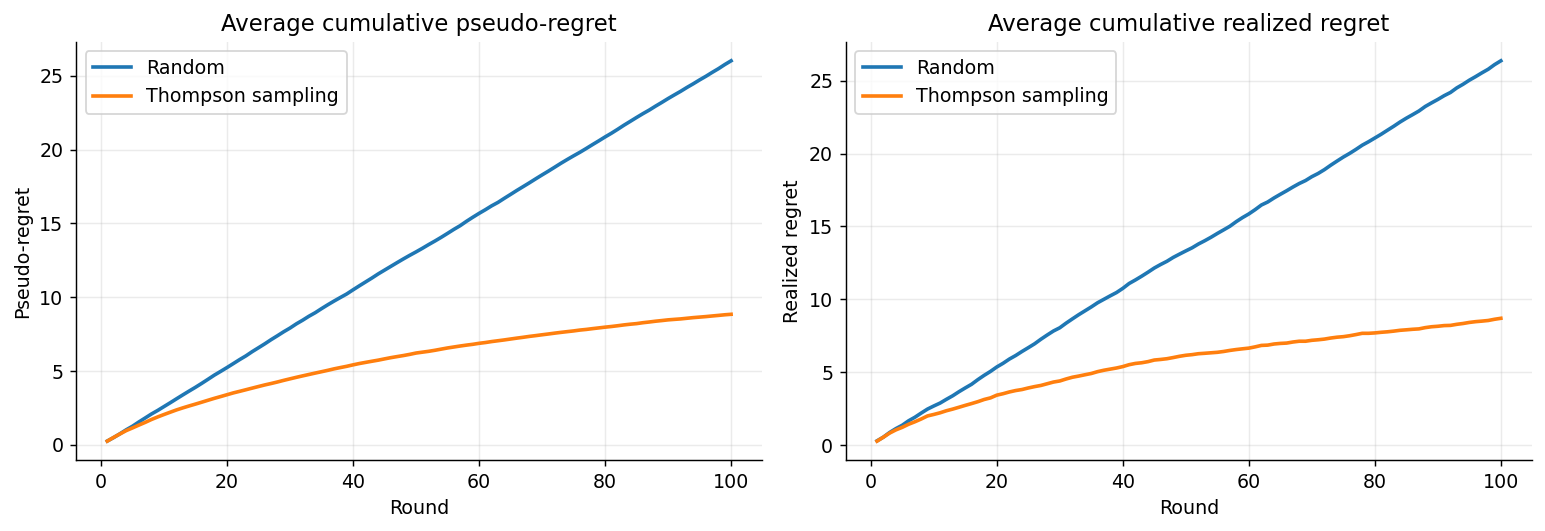

In [8]:
def random_policy(t, counts, successes, failures, rng):
    return int(rng.integers(len(counts)))


def thompson_sampling_policy(t, counts, successes, failures, rng):
    samples = rng.beta(successes + 1.0, failures + 1.0)
    return int(np.argmax(samples))


def run_bandit_policy(policy_fn, probs=DEFAULT_ARM_PROBS, horizon=100, seed=None):
    seed_sequence = np.random.SeedSequence(seed)
    env_sequence, policy_sequence = seed_sequence.spawn(2)
    bandit = BernoulliBandit(probs, rng=np.random.default_rng(env_sequence))
    rng = np.random.default_rng(policy_sequence)
    counts = np.zeros(bandit.n_arms, dtype=int)
    successes = np.zeros(bandit.n_arms, dtype=float)
    failures = np.zeros(bandit.n_arms, dtype=float)

    history = []
    total_reward = 0
    cumulative_pseudo_regret = 0.0

    for t in range(int(horizon)):
        arm = int(policy_fn(t, counts.copy(), successes.copy(), failures.copy(), rng))
        if arm < 0 or arm >= bandit.n_arms:
            raise ValueError(f"Policy returned invalid arm {arm}.")

        reward = bandit.pull(arm)
        counts[arm] += 1
        successes[arm] += reward
        failures[arm] += 1 - reward
        total_reward += reward
        cumulative_pseudo_regret += bandit.best_mean - bandit.probs[arm]

        history.append(
            {
                "t": t + 1,
                "arm": arm,
                "reward": reward,
                "cumulative_reward": total_reward,
                "cumulative_realized_regret": (t + 1) * bandit.best_mean - total_reward,
                "cumulative_pseudo_regret": cumulative_pseudo_regret,
            }
        )

    return {
        "history": history,
        "counts": counts,
        "successes": successes,
        "failures": failures,
        "total_reward": total_reward,
        "cumulative_realized_regret": history[-1]["cumulative_realized_regret"],
        "cumulative_pseudo_regret": cumulative_pseudo_regret,
    }


def evaluate_bandit_policies(policy_fns, probs=DEFAULT_ARM_PROBS, horizon=100, n_runs=200, seed=123):
    master_rng = np.random.default_rng(seed)
    run_seeds = master_rng.integers(0, 2**32 - 1, size=int(n_runs), dtype=np.uint32)
    results = {}

    for name, policy_fn in policy_fns.items():
        pseudo_curves = []
        realized_curves = []
        rewards = []
        pulls = []

        for run_seed in run_seeds:
            result = run_bandit_policy(policy_fn, probs=probs, horizon=horizon, seed=run_seed)
            pseudo_curves.append([row["cumulative_pseudo_regret"] for row in result["history"]])
            realized_curves.append([row["cumulative_realized_regret"] for row in result["history"]])
            rewards.append(result["total_reward"])
            pulls.append(result["counts"])

        results[name] = {
            "mean_pseudo_regret": np.mean(np.asarray(pseudo_curves), axis=0),
            "mean_realized_regret": np.mean(np.asarray(realized_curves), axis=0),
            "mean_total_reward": float(np.mean(rewards)),
            "std_total_reward": float(np.std(rewards)),
            "mean_pulls": np.mean(np.asarray(pulls), axis=0),
        }

    return results


def plot_bandit_policy_results(results):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    for name, result in results.items():
        x = np.arange(1, len(result["mean_pseudo_regret"]) + 1)
        axes[0].plot(x, result["mean_pseudo_regret"], label=name, linewidth=2)
        axes[1].plot(x, result["mean_realized_regret"], label=name, linewidth=2)

    axes[0].set_title("Average cumulative pseudo-regret")
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("Pseudo-regret")
    axes[1].set_title("Average cumulative realized regret")
    axes[1].set_xlabel("Round")
    axes[1].set_ylabel("Realized regret")
    axes[0].legend()
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def summarize_bandit_policy_results(results):
    rows = []
    for name, result in results.items():
        row = {
            "Policy": name,
            "Mean total reward": result["mean_total_reward"],
            "Std total reward": result["std_total_reward"],
            "Final pseudo-regret": result["mean_pseudo_regret"][-1],
            "Final realized regret": result["mean_realized_regret"][-1],
        }
        for arm, value in enumerate(result["mean_pulls"]):
            row[f"Avg pulls arm {arm}"] = value
        rows.append(row)
    display(records_to_html(rows, float_digits=3))


default_policy_fns = {
    "Random": random_policy,
    "Thompson sampling": thompson_sampling_policy,
}

mab_results = evaluate_bandit_policies(default_policy_fns, horizon=100, n_runs=300, seed=123)
summarize_bandit_policy_results(mab_results)
plot_bandit_policy_results(mab_results)


## Try your own bandit policy

Implement a policy with this signature:

```python
def my_policy(t, counts, successes, failures, rng):
    return arm_index
```

Inputs:

- `t`: zero-based round index before choosing the arm;
- `counts`: number of previous pulls for each arm;
- `successes`: number of observed rewards equal to 1 for each arm;
- `failures`: number of observed rewards equal to 0 for each arm;
- `rng`: a NumPy random generator.

The function must return an integer arm index from `0` to `K-1`.


Policy,Mean total reward,Std total reward,Final pseudo-regret,Final realized regret,Avg pulls arm 0,Avg pulls arm 1,Avg pulls arm 2,Avg pulls arm 3
Random,44.100,5.006,26.263,25.900,24.863,25.277,24.943,24.917
Thompson sampling,60.853,6.542,9.396,9.147,5.030,8.937,23.343,62.690
My policy,58.760,15.990,11.405,11.240,9.193,6.593,26.937,57.277


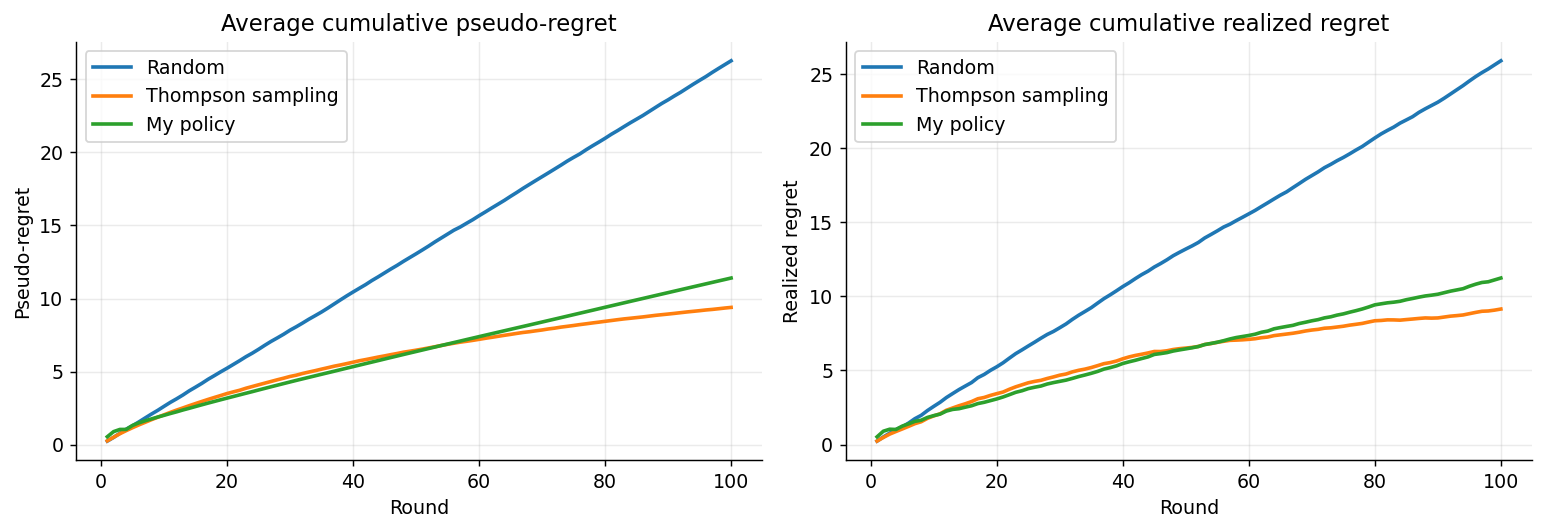

In [5]:
def my_policy(t, counts, successes, failures, rng):
    # Baseline to edit: try every arm once, then exploit the empirical best arm.
    unexplored = np.flatnonzero(counts == 0)
    if len(unexplored) > 0:
        return int(unexplored[0])

    empirical_means = successes / counts
    return int(np.argmax(empirical_means))


custom_policy_fns = {
    "Random": random_policy,
    "Thompson sampling": thompson_sampling_policy,
    "My policy": my_policy,
}

custom_results = evaluate_bandit_policies(custom_policy_fns, horizon=100, n_runs=300, seed=2026)
summarize_bandit_policy_results(custom_results)
plot_bandit_policy_results(custom_results)


# Block 2: Markov decision processes

We use the machine-maintenance MDP from the lecture.

States:

- \(s=1\): the machine is running normally;
- \(s=2\): the machine is broken.

Actions:

- \(a_1\): keep producing, only available in state 1;
- \(a_2\): quick repair, available in state 2;
- \(a_3\): regular repair, available in state 2.


In [9]:
STATES = [1, 2]
STATE_NAMES = {1: "normal", 2: "broken"}
ACTIONS = {
    1: ["a1"],
    2: ["a2", "a3"],
}
ACTION_NAMES = {
    "a1": "produce",
    "a2": "quick repair",
    "a3": "regular repair",
}
REWARDS = {
    (1, "a1"): 10.0,
    (2, "a2"): -5.0,
    (2, "a3"): -2.0,
}
TRANSITIONS = {
    (1, "a1"): np.array([0.7, 0.3]),
    (2, "a2"): np.array([0.6, 0.4]),
    (2, "a3"): np.array([0.4, 0.6]),
}


def transition_row(state, action):
    return TRANSITIONS[(state, action)]


def reward(state, action):
    return REWARDS[(state, action)]


def show_mdp_parameters():
    rows = []
    for state in STATES:
        for action in ACTIONS[state]:
            probs = transition_row(state, action)
            rows.append(
                {
                    "State": f"{state} ({STATE_NAMES[state]})",
                    "Action": f"{action} ({ACTION_NAMES[action]})",
                    "R(s,a)": reward(state, action),
                    "P(1|s,a)": probs[0],
                    "P(2|s,a)": probs[1],
                }
            )
    display(records_to_html(rows, float_digits=3))


show_mdp_parameters()


State,Action,"R(s,a)","P(1|s,a)","P(2|s,a)"
1 (normal),a1 (produce),10.000,0.700,0.300
2 (broken),a2 (quick repair),-5.000,0.600,0.400
2 (broken),a3 (regular repair),-2.000,0.400,0.600


## Finite-horizon dynamic programming

The lecture defines \(V_n(s)\) as the optimal expected total reward when \(n\) periods remain.
The horizon is finite and undiscounted:

\[
V_0(s)=0,\qquad
V_n(s)=\max_{a\in\mathcal{A}(s)}
\left\{R(s,a)+\sum_{s'}P(s'\mid s,a)V_{n-1}(s')\right\}.
\]

The next cells compute this recursion one layer at a time.


In [10]:
def finite_horizon_dp(T):
    T = int(T)
    if T < 0:
        raise ValueError("T must be nonnegative.")

    V = np.zeros((T + 1, len(STATES)), dtype=float)
    policies = [{} for _ in range(T + 1)]
    q_values = [{} for _ in range(T + 1)]
    rows = []

    for n in range(1, T + 1):
        for state in STATES:
            candidates = []
            for action in ACTIONS[state]:
                q = reward(state, action) + transition_row(state, action) @ V[n - 1]
                candidates.append((action, float(q)))
                q_values[n][(state, action)] = float(q)

            best_action, best_value = max(candidates, key=lambda item: item[1])
            policies[n][state] = best_action
            V[n, STATES.index(state)] = best_value

        rows.append(
            {
                "n": n,
                "V_n(1)": V[n, 0],
                "V_n(2)": V[n, 1],
                "take a2 at s=2": q_values[n].get((2, "a2"), np.nan),
                "take a3 at s=2": q_values[n].get((2, "a3"), np.nan),
                "pi_n*(2)": policies[n][2],
            }
        )

    return V, policies, q_values, rows


V4, policies4, q_values4, rows4 = finite_horizon_dp(4)
display(records_to_html(rows4, float_digits=2))


n,V_n(1),V_n(2),take a2 at s=2,take a3 at s=2,pi_n*(2)
1,10.00,-2.00,-5.00,-2.00,a3
2,16.40,0.80,0.20,0.80,a3
3,21.72,5.16,5.16,5.04,a2
4,26.75,10.10,10.10,9.78,a2


In [11]:
def show_finite_horizon_step(T=4, n=4):
    T = int(T)
    n = int(min(max(1, n), T))
    V, policies, q_values, rows = finite_horizon_dp(T)
    prev_v1, prev_v2 = V[n - 1]
    q_a2 = q_values[n][(2, "a2")]
    q_a3 = q_values[n][(2, "a3")]

    display(Markdown(f"### Step n = {n} with {T} total periods"))
    display(records_to_html(rows[:n], float_digits=2))

    display(
        Markdown(
            rf'''
            Using \(V_{{{n-1}}}(1)={prev_v1:.2f}\) and \(V_{{{n-1}}}(2)={prev_v2:.2f}\):

            \[
            \begin{{aligned}}
            Q_n(2,a_2) &= -5 + 0.6 V_{{{n-1}}}(1)+0.4 V_{{{n-1}}}(2) = {q_a2:.2f},\\
            Q_n(2,a_3) &= -2 + 0.4 V_{{{n-1}}}(1)+0.6 V_{{{n-1}}}(2) = {q_a3:.2f}.
            \end{{aligned}}
            \]

            Therefore \(\pi^*_{{{n}}}(2)={policies[n][2]}\).
            '''
        )
    )

    xs = np.arange(T + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(xs, V[:, 0], marker="o", label="V_n(1): normal")
    ax.plot(xs, V[:, 1], marker="o", label="V_n(2): broken")
    ax.axvline(n, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("n periods remaining")
    ax.set_ylabel("Optimal expected total reward")
    ax.set_title("Finite-horizon values")
    ax.legend()
    plt.show()


def finite_horizon_dashboard():
    if not WIDGETS_AVAILABLE:
        show_finite_horizon_step(T=4, n=4)
        return

    T_slider = widgets.IntSlider(value=4, min=1, max=20, step=1, description="T")
    n_slider = widgets.IntSlider(value=4, min=1, max=4, step=1, description="n")

    def sync_n_max(change):
        n_slider.max = change["new"]
        if n_slider.value > n_slider.max:
            n_slider.value = n_slider.max

    T_slider.observe(sync_n_max, names="value")
    out = widgets.interactive_output(show_finite_horizon_step, {"T": T_slider, "n": n_slider})
    display(widgets.VBox([widgets.HBox([T_slider, n_slider]), out]))


finite_horizon_dashboard()


## Fixed-policy value evaluation

Now fix a stationary policy.
Since state 1 only has one action, a deterministic policy only needs to choose between \(a_2\) and \(a_3\) in state 2.

For a fixed policy \(\pi\), the Bellman expectation equation is:

\[
V^\pi = r_\pi + \gamma P_\pi V^\pi.
\]

Equivalently:

\[
(I-\gamma P_\pi)V^\pi=r_\pi.
\]

The slider below changes \(\gamma\), so you can see how discounting affects the values.


In [12]:
def policy_matrices(action_s2="a3"):
    if action_s2 not in ACTIONS[2]:
        raise ValueError("action_s2 must be 'a2' or 'a3'.")

    policy = {
        1: "a1",
        2: action_s2,
    }
    P_pi = np.vstack([transition_row(state, policy[state]) for state in STATES])
    r_pi = np.array([reward(state, policy[state]) for state in STATES], dtype=float)
    return policy, P_pi, r_pi


def evaluate_policy_direct(gamma=0.9, action_s2="a3"):
    gamma = float(gamma)
    if gamma < 0 or gamma >= 1:
        raise ValueError("Use 0 <= gamma < 1 for the discounted infinite-horizon solve.")

    policy, P_pi, r_pi = policy_matrices(action_s2)
    values = np.linalg.solve(np.eye(len(STATES)) - gamma * P_pi, r_pi)
    return policy, P_pi, r_pi, values


def evaluate_policy_iterative(gamma=0.9, action_s2="a3", iterations=30):
    policy, P_pi, r_pi = policy_matrices(action_s2)
    values = np.zeros(len(STATES), dtype=float)
    trace = [values.copy()]

    for _ in range(int(iterations)):
        values = r_pi + gamma * P_pi @ values
        trace.append(values.copy())

    return np.asarray(trace)


def show_policy_evaluation(gamma=0.9, action_s2="a3", iterations=30):
    policy, P_pi, r_pi, values = evaluate_policy_direct(gamma=gamma, action_s2=action_s2)
    trace = evaluate_policy_iterative(gamma=gamma, action_s2=action_s2, iterations=iterations)

    rows = [
        {
            "State": f"{state} ({STATE_NAMES[state]})",
            "Policy action": f"{policy[state]} ({ACTION_NAMES[policy[state]]})",
            "V_direct": values[i],
            f"V_iter after {iterations} iters": trace[-1, i],
        }
        for i, state in enumerate(STATES)
    ]

    display(Markdown(f"### Fixed policy: pi(1)=a1, pi(2)={action_s2}; gamma={gamma:.2f}"))
    display(records_to_html(rows, float_digits=3))

    matrix_rows = []
    A = np.eye(len(STATES)) - gamma * P_pi
    for i, state in enumerate(STATES):
        matrix_rows.append(
            {
                "Equation row": f"s={state}",
                "coef V(1)": A[i, 0],
                "coef V(2)": A[i, 1],
                "rhs r": r_pi[i],
            }
        )
    display(records_to_html(matrix_rows, float_digits=3))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(trace[:, 0], marker="o", markersize=3, label="Iterative V(1)")
    ax.plot(trace[:, 1], marker="o", markersize=3, label="Iterative V(2)")
    ax.axhline(values[0], color="C0", linestyle="--", linewidth=1, label="Direct V(1)")
    ax.axhline(values[1], color="C1", linestyle="--", linewidth=1, label="Direct V(2)")
    ax.set_xlabel("Iteration k")
    ax.set_ylabel("Value")
    ax.set_title("Policy evaluation by repeated Bellman updates")
    ax.legend()
    plt.show()


def policy_evaluation_dashboard():
    if not WIDGETS_AVAILABLE:
        show_policy_evaluation(gamma=0.9, action_s2="a3", iterations=30)
        return

    gamma_slider = widgets.FloatSlider(
        value=0.9,
        min=0.0,
        max=0.99,
        step=0.01,
        readout_format=".2f",
        description="gamma",
    )
    action_dropdown = widgets.Dropdown(
        options=[("a2: quick repair", "a2"), ("a3: regular repair", "a3")],
        value="a3",
        description="pi(2)",
    )
    iter_slider = widgets.IntSlider(value=30, min=1, max=100, step=1, description="iters")
    out = widgets.interactive_output(
        show_policy_evaluation,
        {"gamma": gamma_slider, "action_s2": action_dropdown, "iterations": iter_slider},
    )
    display(widgets.VBox([widgets.HBox([gamma_slider, action_dropdown, iter_slider]), out]))


policy_evaluation_dashboard()


In [ ]:
def compare_gammas(gammas=(0.0, 0.3, 0.6, 0.9, 0.99), action_s2="a3"):
    rows = []
    values_by_gamma = []

    for gamma in gammas:
        _, _, _, values = evaluate_policy_direct(gamma=gamma, action_s2=action_s2)
        values_by_gamma.append(values)
        rows.append(
            {
                "gamma": gamma,
                "pi(2)": action_s2,
                "V^pi(1)": values[0],
                "V^pi(2)": values[1],
            }
        )

    display(records_to_html(rows, float_digits=3))

    values_by_gamma = np.asarray(values_by_gamma)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(gammas, values_by_gamma[:, 0], marker="o", label="V^pi(1)")
    ax.plot(gammas, values_by_gamma[:, 1], marker="o", label="V^pi(2)")
    ax.set_xlabel("gamma")
    ax.set_ylabel("Direct-solve value")
    ax.set_title(f"Effect of gamma under pi(2)={action_s2}")
    ax.legend()
    plt.show()


compare_gammas(action_s2="a3")
compare_gammas(action_s2="a2")
